<a href="https://colab.research.google.com/github/Prakat-star/FDS/blob/main/lab8_bct024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

logistic regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
   accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_score,
    recall_score
)
np.random.seed(42)
x=np.random.rand(200,2)*10
y=(4*x[:,0]-3*x[:,1]+np.random.randn(200)>0).astype(int)
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)
log_reg=LogisticRegression()
log_reg.fit(xtrain,ytrain)
ypred=log_reg.predict(xtest)
ypredprob=log_reg.predict_proba(xtest)[:,1]
accuracy=accuracy_score(ytest,ypred)
precision=precision_score(ytest,ypred)
recall=recall_score(ytest,ypred)
print(f"Accuracy:,{accuracy:.2f}")
print(f"Precision:,{precision:.2f}")
print(f"Recall:,{recall:.2f}")



Accuracy:,0.98
Precision:,0.97
Recall:,1.00


In [ ]:
print("\nClassification  Report:\n",classification_report(ytest,ypred))
print("\nConfusion Matrix:\n",confusion_matrix(ytest,ypred))


Classification  Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       0.97      1.00      0.99        38

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Confusion Matrix:
 [[21  1]
 [ 0 38]]


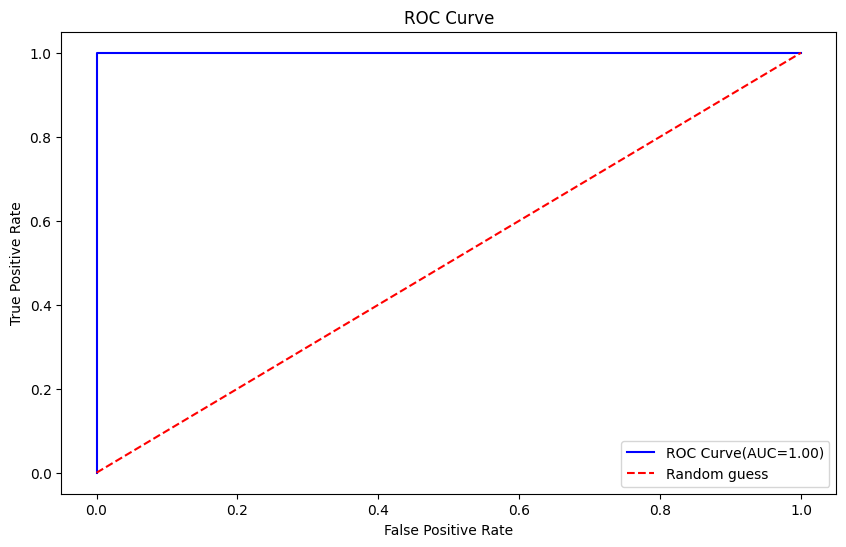

In [ ]:
fpr,tpr,thresholds=roc_curve(ytest,ypredprob)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(10,6))
plt.plot(fpr,tpr,color="blue",label=f"ROC Curve(AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],color='red',linestyle='--',label="Random guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

working with titanic dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
train = pd.read_csv(url)

train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: >

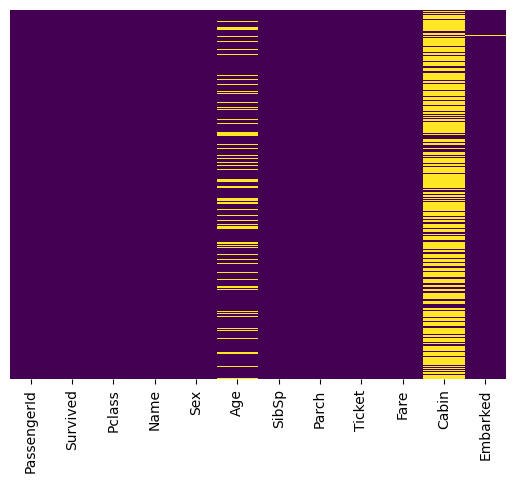

In [ ]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

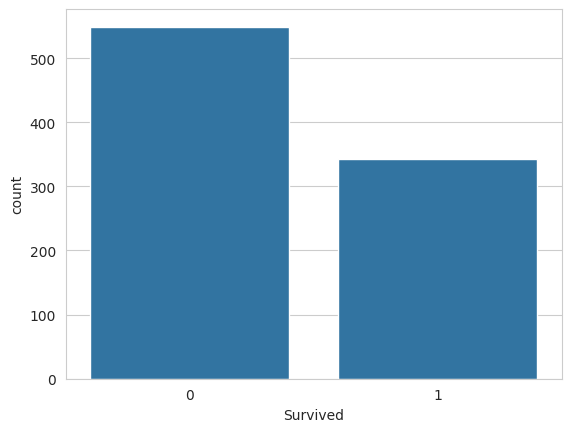

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x="Survived",data=train)


<Axes: xlabel='Survived', ylabel='count'>

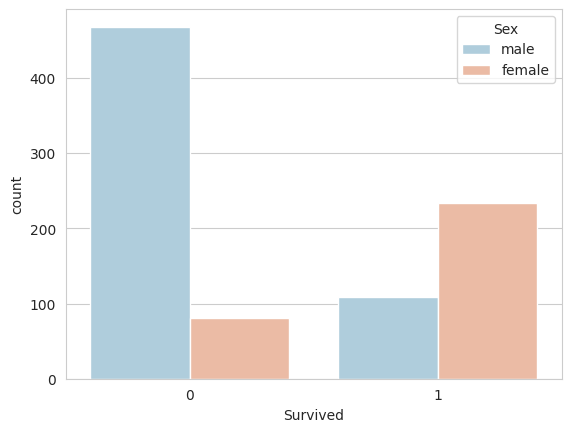

In [ ]:
sns.countplot(x="Survived",hue="Sex",data=train,palette="RdBu_r")

<Axes: xlabel='Survived', ylabel='count'>

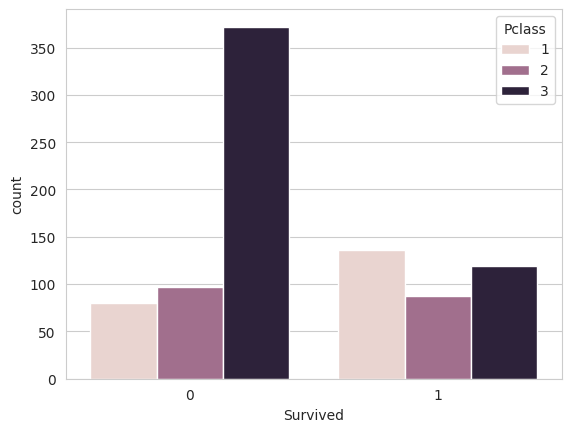

In [ ]:
sns.countplot(x="Survived",hue="Pclass",data=train)

/tmp/ipykernel_648/2747699129.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(),kde=False,bins=30)


<Axes: xlabel='Age'>

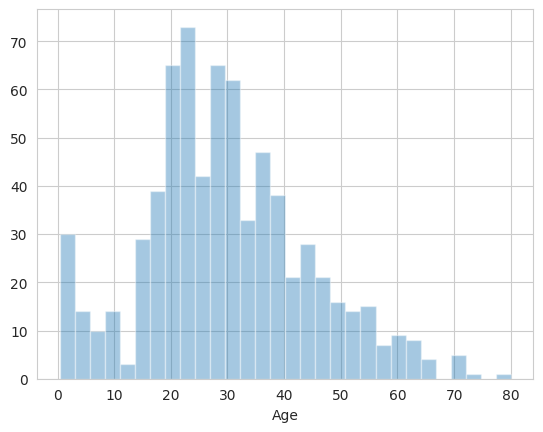

In [ ]:
sns.distplot(train['Age'].dropna(),kde=False,bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

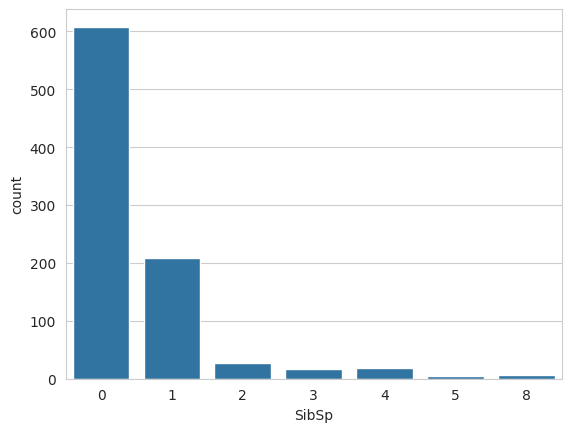

In [ ]:
sns.countplot(x='SibSp',data=train)

<Axes: >

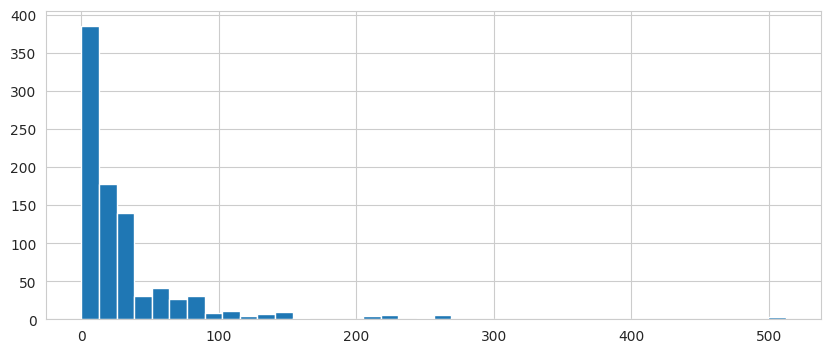

In [ ]:
import cufflinks as cf
train['Fare'].hist(bins=40,figsize=(10,4))

<Axes: xlabel='Parch', ylabel='count'>

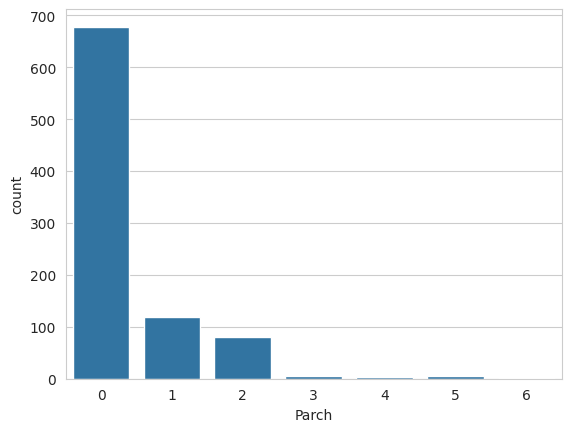

In [ ]:
sns.countplot(x='Parch',data=train)

<Axes: xlabel='Pclass', ylabel='Age'>

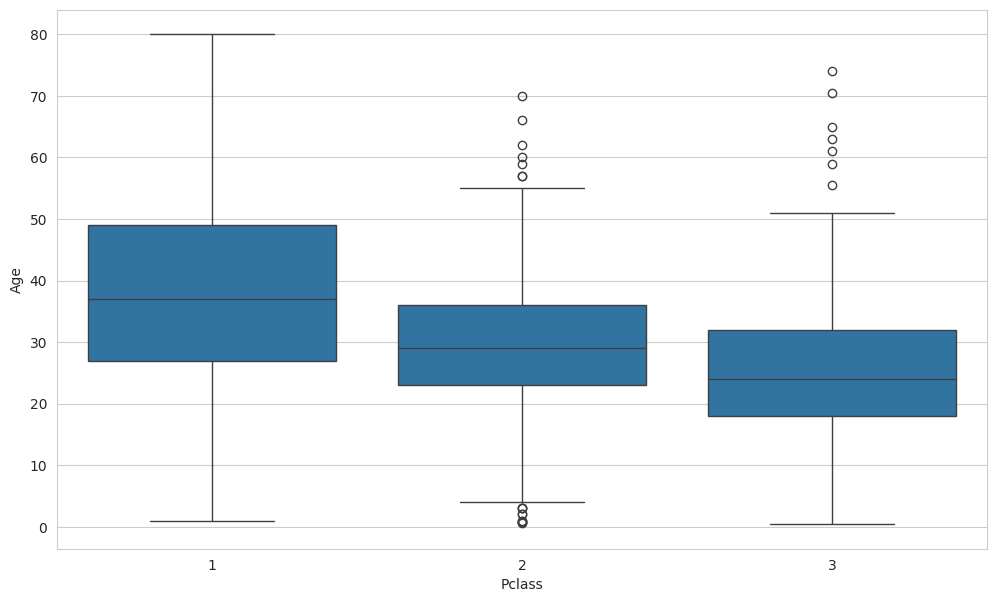

In [ ]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass',y='Age',data=train)

In [ ]:
def inputeage(row):
  age=row['Age']
  pclass=row['Pclass']
  if pd.isnull(age):
    if pclass==1:
      return 37
    elif pclass==2:
      return 29
    else:
      return 24
  else:
    return age



<Axes: >

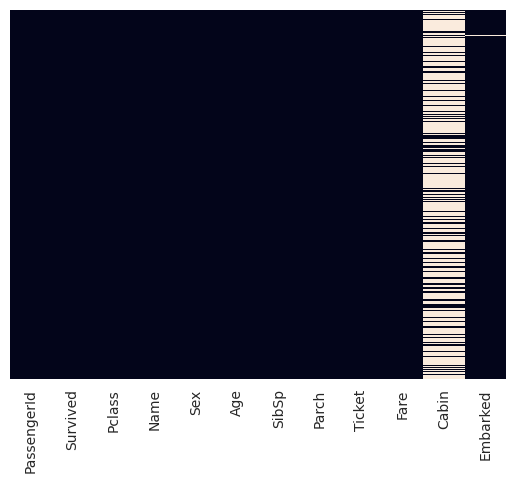

In [ ]:
train['Age']=train[['Age','Pclass']].apply(inputeage,axis=1)
sns.heatmap(train.isnull(),yticklabels=False,cbar=False)

In [ ]:
train.drop('Cabin',axis=1,inplace=True)
train.dropna(inplace=True)
sex=pd.get_dummies(train['Sex'],drop_first=True)
sex=sex.astype(int)
sex.head()

,male
0,1
1,0
2,0
3,0
4,1


In [ ]:
embark=pd.get_dummies(train['Embarked'],drop_first=True)
embark=embark.astype(int)
embark.head()

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [ ]:
train=pd.concat([train,sex,embark],axis=1)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,0,1


In [ ]:
train.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


In [ ]:
train.tail()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
886,887,0,2,27.0,0,0,13.00,1,0,1
887,888,1,1,19.0,0,0,30.00,0,0,1
888,889,0,3,24.0,1,2,23.45,0,0,1
889,890,1,1,26.0,0,0,30.00,1,0,0
890,891,0,3,32.0,0,0,7.75,1,1,0


In [ ]:
train.drop("PassengerId",axis=1,inplace=True)
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [ ]:
pclass=pd.get_dummies(train['Pclass'])
pclass=pclass.astype(int)
pclass.head()

,1,2,3
0,0,0,1
1,1,0,0
2,0,0,1
3,1,0,0
4,0,0,1


In [ ]:
x=train.drop('Survived',axis=1)
y=train['Survived']
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=101)
from sklearn.linear_model import LogisticRegression
logmodel=LogisticRegression()
logmodel.fit(xtrain,ytrain)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [ ]:
predictions=logmodel.predict(xtest)
from sklearn.metrics import classification_report
print(classification_report(ytest,predictions))


              precision    recall  f1-score   support

           0       0.83      0.90      0.86       163
           1       0.82      0.71      0.76       104

    accuracy                           0.83       267
   macro avg       0.83      0.81      0.81       267
weighted avg       0.83      0.83      0.83       267



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(ytest,predictions)

array([[147,  16],
       [ 30,  74]])